# Pengembangan Model ML Berbasis Regresi — Valuasi Harga Hunian di Tangerang Selatan

> **Final Project — Study Club Data Science Beginner, KSM Veterantech UPNVJ**

| | |
|---|---|
| **Nama** | Hasan Shofiyyur Rahman |
| **NIM** | 2410512011 |

```
Workflow: Data Collecting => EDA => Preprocessing => Modeling => Evaluation
```

## A. Data Collecting

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


In [44]:
DATA_PATH = os.path.join('..', 'data', 'Dataset_HousePricing_South_Tangerang.csv')
df = pd.read_csv(DATA_PATH, encoding='latin1')
print(f'Dataset dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')
df.head()

Dataset dimuat: 29420 baris, 7 kolom


,nav-link href,listing-location,price,bed,bath,listing-floorarea,listing-floorarea 2
0,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","6,9 M",5.0,5.0,420 m²,Rp 20.720.721 per m²
1,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","4,5 M",3.0,3.0,190 m²,Rp 12.747.875 per m²
2,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","3,95 M",3.0,3.0,132 m²,Rp 30.859.375 per m²
3,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","3,3 M",4.0,3.0,220 m²,Rp 18.333.333 per m²
4,https://www.rumah.com/listing-properti/dijual-...,"Gading Serpong, Tangerang Selatan, Banten","3,5 M",3.0,2.0,180 m²,Rp 27.777.778 per m²


In [45]:
df.info()
print('\n')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 29420 entries, 0 to 29419
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nav-link href        29420 non-null  str    
 1   listing-location     29420 non-null  str    
 2   price                29420 non-null  str    
 3   bed                  29282 non-null  float64
 4   bath                 29215 non-null  float64
 5   listing-floorarea    29420 non-null  str    
 6   listing-floorarea 2  29383 non-null  str    
dtypes: float64(2), str(5)
memory usage: 1.6 MB




,bed,bath
count,29282.000000,29215.000000
mean,3.754457,2.986137
std,1.356762,1.359788
min,1.000000,1.000000
25%,3.000000,2.000000
50%,4.000000,3.000000
75%,4.000000,4.000000
max,10.000000,10.000000


## B. Exploratory Data Analysis (EDA)

In [46]:
print('Kolom:', df.columns.tolist())
print('\nMissing Values:')
print(df.isnull().sum())
print(f'\nDuplikat: {df.duplicated().sum()}')

Kolom: ['nav-link href', 'listing-location', 'price', 'bed', 'bath', 'listing-floorarea', 'listing-floorarea 2']

Missing Values:
nav-link href            0
listing-location         0
price                    0
bed                    138
bath                   205
listing-floorarea        0
listing-floorarea 2     37
dtype: int64

Duplikat: 5241


In [47]:
# Hapus duplikat
df = df.drop_duplicates()
print(f'Setelah hapus duplikat: {df.shape[0]} baris')

Setelah hapus duplikat: 24179 baris


## C. Data Preprocessing

In [48]:
# --- Cleaning kolom price ---
# Format asli: '6,9 M' (Miliar), '850 jt' (Juta)
def clean_price(val):
    if pd.isna(val): return np.nan
    val = str(val).strip().replace(',', '.')
    val_lower = val.lower()
    if 'm' in val_lower and 'jt' not in val_lower:
        num = re.findall(r'[\d.]+', val)
        return float(num[0]) * 1_000_000_000 if num else np.nan
    elif 'jt' in val_lower:
        num = re.findall(r'[\d.]+', val)
        return float(num[0]) * 1_000_000 if num else np.nan
    else:
        num = re.findall(r'[\d.]+', val)
        return float(num[0]) if num else np.nan

df['price_cleaned'] = df['price'].apply(clean_price)
print('Contoh harga setelah cleaning:')
print(df[['price', 'price_cleaned']].head(10))

Contoh harga setelah cleaning:
    price  price_cleaned
0   6,9 M   6.900000e+09
1   4,5 M   4.500000e+09
2  3,95 M   3.950000e+09
3   3,3 M   3.300000e+09
4   3,5 M   3.500000e+09
5   4,5 M   4.500000e+09
6   4,5 M   4.500000e+09
7   4,5 M   4.500000e+09
8   4,5 M   4.500000e+09
9   2,2 M   2.200000e+09


In [49]:
# --- Cleaning kolom listing-floorarea ---
# Format asli: '420 m\u00b2'
def clean_floorarea(val):
    if pd.isna(val): return np.nan
    num = re.findall(r'[\d.]+', str(val))
    return float(num[0]) if num else np.nan

df['floor_area_sqm'] = df['listing-floorarea'].apply(clean_floorarea)
print('Contoh luas bangunan setelah cleaning:')
print(df[['listing-floorarea', 'floor_area_sqm']].head(10))

Contoh luas bangunan setelah cleaning:
  listing-floorarea  floor_area_sqm
0            420 m²           420.0
1            190 m²           190.0
2            132 m²           132.0
3            220 m²           220.0
4            180 m²           180.0
5            194 m²           194.0
6            160 m²           160.0
7            190 m²           190.0
8            120 m²           120.0
9            140 m²           140.0


In [50]:
# --- Extract kecamatan dari listing-location ---
# Format: 'Area, Kecamatan, Banten' => ambil bagian ke-2 (kecamatan)
loc_parts = df['listing-location'].str.split(',')
df['kecamatan'] = loc_parts.apply(
    lambda x: x[1].strip().title() if isinstance(x, list) and len(x) >= 3 else
              (x[0].strip().title() if isinstance(x, list) else np.nan)
)

print(f'Jumlah kecamatan unik: {df["kecamatan"].nunique()}')
print('\nTop 10 Kecamatan:')
print(df['kecamatan'].value_counts().head(10))

Jumlah kecamatan unik: 473

Top 10 Kecamatan:
kecamatan
Tangerang Selatan    9129
Bintaro              5000
Bsd                  2229
Pamulang             1102
Ciputat               951
Gading Serpong        920
Serpong               919
Pondok Aren           745
Ciputat Timur         647
Serpong Utara         406
Name: count, dtype: int64


In [51]:
# Hapus baris dengan missing values pada kolom penting
important_cols = ['bed', 'bath', 'price_cleaned', 'floor_area_sqm', 'kecamatan']
df = df.dropna(subset=important_cols)
print(f'Data setelah hapus missing: {df.shape[0]} baris')

# Filter outlier harga ekstrem (1st - 99th percentile)
q1 = df['price_cleaned'].quantile(0.01)
q99 = df['price_cleaned'].quantile(0.99)
df = df[(df['price_cleaned'] >= q1) & (df['price_cleaned'] <= q99)]
print(f'Data setelah filter outlier: {df.shape[0]} baris')

Data setelah hapus missing: 24016 baris
Data setelah filter outlier: 23540 baris


In [52]:
# Encoding kecamatan
le = LabelEncoder()
df['kecamatan_encoded'] = le.fit_transform(df['kecamatan'])
print('Label Encoding selesai.')

Label Encoding selesai.


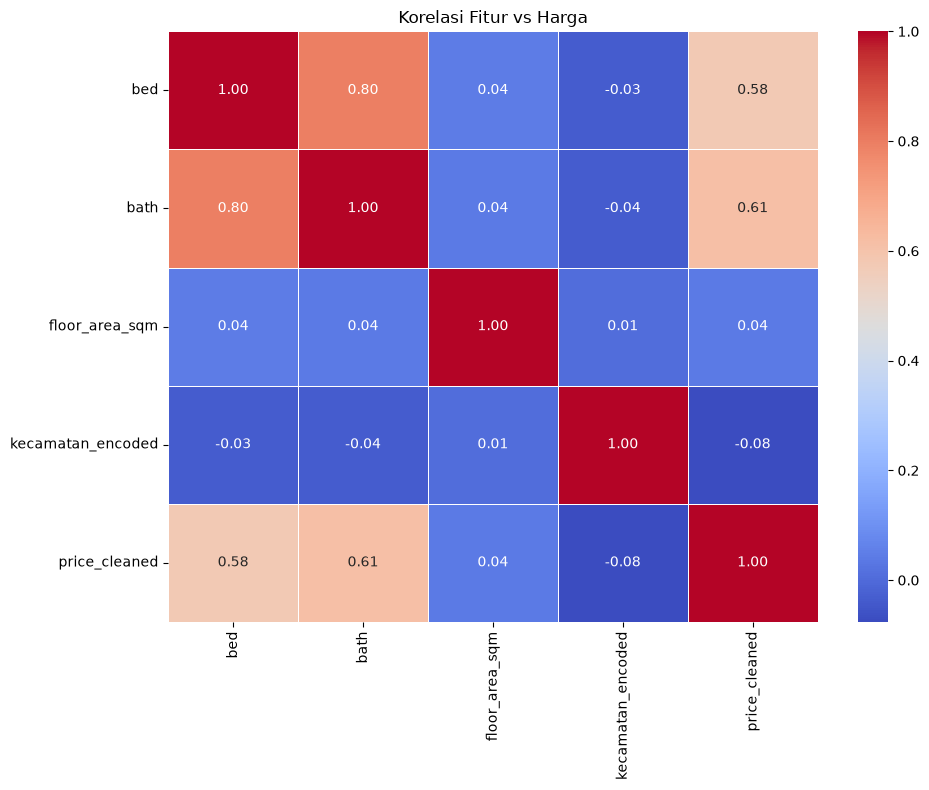


Korelasi terhadap Harga:
price_cleaned        1.000000
bath                 0.613837
bed                  0.577126
floor_area_sqm       0.039245
kecamatan_encoded   -0.075921
Name: price_cleaned, dtype: float64


In [53]:
# Korelasi
plt.figure(figsize=(10, 8))
corr = df[['bed','bath','floor_area_sqm','kecamatan_encoded','price_cleaned']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Fitur vs Harga')
plt.tight_layout()
plt.show()

print('\nKorelasi terhadap Harga:')
print(corr['price_cleaned'].sort_values(ascending=False))

### Train-Test Split & Scaling

In [54]:
X = df[['floor_area_sqm', 'bed', 'bath', 'kecamatan_encoded']]
y = df['price_cleaned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Data Latih: {X_train.shape[0]} | Data Uji: {X_test.shape[0]}')

Data Latih: 18832 | Data Uji: 4708


## D. Modeling

In [55]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print(f'Linear Regression => MAE: Rp {mean_absolute_error(y_test, y_pred_lr):,.0f} | R2: {r2_score(y_test, y_pred_lr):.4f}')

Linear Regression => MAE: Rp 1,395,954,091 | R2: 0.4166


In [56]:
# Random Forest (Base)
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train_scaled, y_train)
y_pred_base = rf_base.predict(X_test_scaled)

mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)
print(f'Random Forest Base => MAE: Rp {mae_base:,.0f} | R2: {r2_base:.4f}')

Random Forest Base => MAE: Rp 747,577,521 | R2: 0.7759


## E. Evaluation & Hyperparameter Tuning

In [57]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_tuned = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist, n_iter=10, cv=3, n_jobs=-1, random_state=42, verbose=0
)
rf_tuned.fit(X_train_scaled, y_train)
best_rf = rf_tuned.best_estimator_

print(f'Best Params: {rf_tuned.best_params_}')

Best Params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30}


In [58]:
y_pred_tuned = best_rf.predict(X_test_scaled)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f'RF Tuned => MAE: Rp {mae_tuned:,.0f} | R2: {r2_tuned:.4f}')
print(f'Peningkatan R2: +{r2_tuned - r2_base:.4f}')

RF Tuned => MAE: Rp 756,268,236 | R2: 0.7805
Peningkatan R2: +0.0047


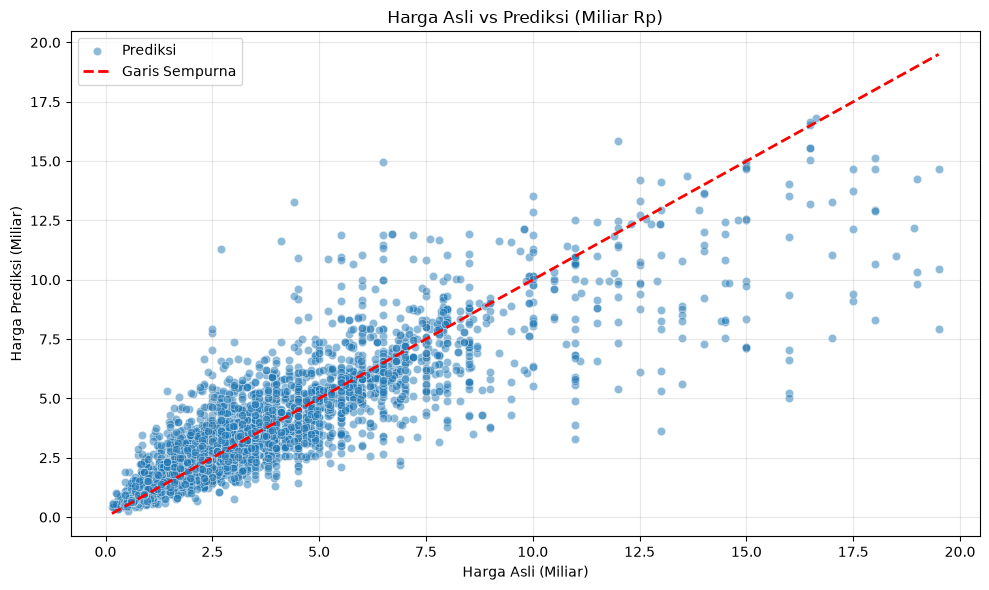

In [59]:
# Visualisasi: Harga Asli vs Prediksi
plt.figure(figsize=(10, 6))
y_test_m = y_test / 1e9
y_pred_m = y_pred_tuned / 1e9
sns.scatterplot(x=y_test_m, y=y_pred_m, alpha=0.5, label='Prediksi')
lims = [min(y_test_m.min(), y_pred_m.min()), max(y_test_m.max(), y_pred_m.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Garis Sempurna')
plt.title('Harga Asli vs Prediksi (Miliar Rp)')
plt.xlabel('Harga Asli (Miliar)')
plt.ylabel('Harga Prediksi (Miliar)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

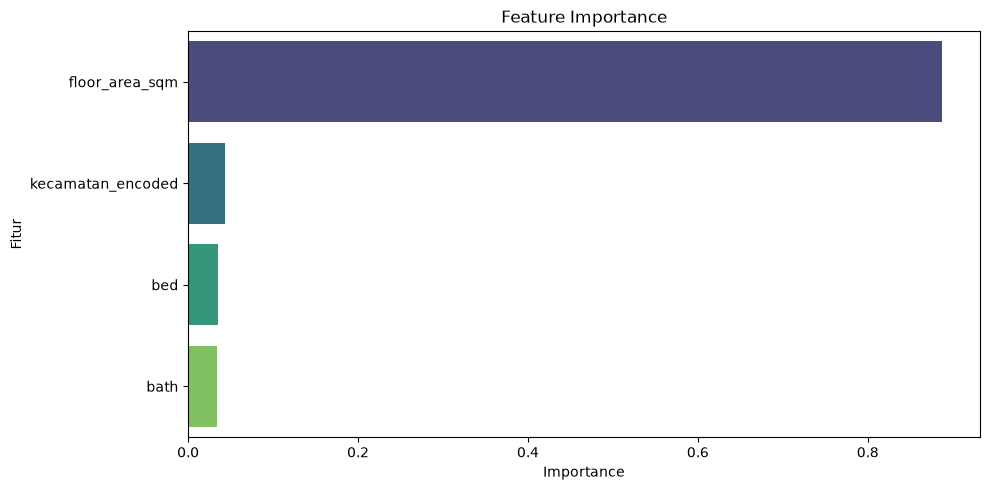

In [60]:
# Feature Importance
fi = pd.DataFrame({'Fitur': X.columns, 'Importance': best_rf.feature_importances_})
fi = fi.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Fitur', data=fi, palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## Kesimpulan

1. **Random Forest Regressor** setelah tuning menghasilkan performa terbaik
2. **Luas bangunan** (`floor_area_sqm`) menjadi fitur paling berpengaruh
3. Model mampu menjelaskan ~78% variasi harga (R² ≈ 0.78)

---
*Final Project — KSM Veterantech UPNVJ, 2026*